# Habit Formation with Portfolio Choice

The [habit formation model](./HabitConsumerType.ipynb) extends the workhorse consumption-saving model to include consumption habits, where agents get utility from the ratio of consumption to a habit stock. The [portfolio choice model](../ConsPortfolioModel/RiskyAssetConsumerType.ipynb) extends the same baseline model to allow agents to allocate their wealth between a risk-free and a risky asset.

This notebook develops the mathematical framework for a model that combines **both** extensions: agents have consumption habits *and* can choose their portfolio allocation. This is a natural combination: an agent whose utility depends on maintaining consumption relative to a habit stock will have different attitudes toward portfolio risk than an agent with standard preferences.

We derive the model statement, end-of-period value functions, first order conditions, and the solution algorithm, following the style established in the habit formation notebook.

$\newcommand{\CRRA}{\rho}$
$\newcommand{\LivPrb}{\mathsf{S}}$
$\newcommand{\PermGroFac}{\Gamma}$
$\newcommand{\Rfree}{\mathsf{R}}$
$\newcommand{\Risky}{\mathfrak{R}}$
$\newcommand{\DiscFac}{\beta}$
$\newcommand{\HabitWgt}{\alpha}$
$\newcommand{\HabitRte}{\lambda}$


## Model Statement

The habit-portfolio consumer faces the following problem:

\begin{eqnarray*}
\text{v}_t(m_t,h_t) &=& \max_{c_t, s_t}u(c_t,h_t) + \DiscFac \LivPrb_t \mathbb{E}_{t} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{(1-\HabitWgt)(1-\CRRA)} \text{v}_{t+1}(m_{t+1}, h_{t+1}) \right] \\
&\text{s.t.}&  \\
a_t &=& m_t - c_t, \\
H_t &=& \HabitRte c_t + (1-\HabitRte) h_t, \\
a_t &\geq& 0, \\
s_t &\in& [0,1], \\
R_{t+1} &=& s_t \Risky_{t+1} + (1-s_t) \Rfree_{t+1}, \\
m_{t+1} &=& a_t R_{t+1}/(\PermGroFac_{t+1} \psi_{t+1}) + \theta_{t+1}, \\
h_{t+1} &=& H_t / (\PermGroFac_{t+1} \psi_{t+1}), \\
(\psi_{t+1},\theta_{t+1}) &\sim& F_{t+1}, \\
\Risky_{t+1} &\sim& G, \\
\mathbb{E}[\psi] &=& 1, \\
u(c,h) &=& \frac{(c/h^\HabitWgt)^{1-\CRRA}}{1-\CRRA}.
\end{eqnarray*}

Compared to the habit-only model, there are two key differences:

1. The agent has a **second control** $s_t \in [0,1]$, the share of retained assets allocated to the risky asset. The portfolio return $R_{t+1}$ is the weighted average of risky and risk-free returns.

2. As in the portfolio choice model, **borrowing is not allowed**: the artificial borrowing constraint is hardwired at $a_t \geq 0$. Allowing an agent to borrow while holding an asset with unbounded negative returns is economically problematic.

The model nests several special cases:
- $\HabitWgt \to 0$: reduces to `RiskyAssetConsumerType` (portfolio choice, no habits)
- $\HabitRte = 0$: habits are "frozen" and don't evolve; effectively a portfolio choice model with modified risk aversion
- $s_t$ fixed at $0$: reduces to `HabitConsumerType` (habits, no portfolio choice)
- $\HabitWgt \to 0$ and $s_t$ fixed at $0$: reduces to `IndShockConsumerType`

## Solving the Habit-Portfolio Model

The key insight from the portfolio choice model is that although $c_t$ and $s_t$ are chosen simultaneously, the problem is more easily solved by imagining them to be made **sequentially**. First, the agent chooses how much to consume $c_t$ (and hence how much to save $a_t$), and *then* they choose how to split that wealth between the risky and risk-free asset with $s_t$.

When solving by backward induction, HARK thus solves the portfolio allocation problem *first*. Fixing a grid of end-of-period states, the solver finds the $s_t$ that maximizes expected value at each gridpoint. Optimal consumption $c_t$ associated with each end-of-period state can then be found using the extended EGM approach from the habit model.

The state space at decision time is $(m_t, h_t)$, exactly as in the habit-only model. The end-of-period state space is $(a_t, H_t, s_t)$, where $s_t$ is "used up" once asset returns are realized.

### End-of-period value

We define the end-of-period value function over retained assets $a_t$, post-consumption habit stock $H_t$, and risky share $s_t$:

\begin{align*}
\mathfrak{v}_t(a_t,H_t, s_t) &= \DiscFac \LivPrb_t \mathbb{E}_{t} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{(1-\HabitWgt)(1-\CRRA)} \text{v}_{t+1}(m_{t+1}, h_{t+1}) \right] \\
&\text{s.t.} \\
R_{t+1} &= s_t \Risky_{t+1} + (1-s_t) \Rfree_{t+1}, \\
m_{t+1} &= a_t R_{t+1}/(\PermGroFac_{t+1} \psi_{t+1}) + \theta_{t+1}, \\
h_{t+1} &= H_t / (\PermGroFac_{t+1} \psi_{t+1}), \\
(\psi_{t+1},\theta_{t+1}) &\sim F_{t+1}, \\
\Risky_{t+1} &\sim G.
\end{align*}

Note the crucial structural difference from the habit-only model: next period's market resources $m_{t+1}$ now depend on the **portfolio return** $R_{t+1}$ rather than a deterministic $\Rfree_{t+1}$. However, the habit stock evolution is unchanged: $h_{t+1} = H_t / (\PermGroFac_{t+1} \psi_{t+1})$ does not depend on asset returns.

### Marginal values of end-of-period states

The marginal values with respect to each end-of-period state are:

\begin{align*}
\mathfrak{v}_t^a(a_t,H_t,s_t) &= \DiscFac \LivPrb_t \mathbb{E}_{t} \left[ R_{t+1} (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^m(m_{t+1}, h_{t+1}) \right], \\
\mathfrak{v}_t^H(a_t,H_t,s_t) &= \DiscFac \LivPrb_t  \mathbb{E}_{t} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^h(m_{t+1}, h_{t+1}) \right], \\
\mathfrak{v}_t^s(a_t,H_t,s_t) &= \DiscFac \LivPrb_t \mathbb{E}_{t} \left[ a_t(\Risky_{t+1} - \Rfree_{t+1}) (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^m(m_{t+1}, h_{t+1}) \right].
\end{align*}

The first two expressions parallel the habit-only model, except that the return factor appearing in $\mathfrak{v}_t^a$ is now the stochastic portfolio return $R_{t+1}$ rather than the deterministic $\Rfree_{t+1}$. The third expression, for the marginal value of the risky share, is new.

### Decomposing expectations: the intermediate value function

When income shocks and risky returns are independent ($F_t \perp G$, which is the default in HARK), we can decompose the expectations into two stages. Define the **intermediate** (or "medium") value function as the expectation over income shocks only, conditional on a realized portfolio return:

\begin{align*}
\overline{v}(b_t, H_t) &\equiv \DiscFac \LivPrb_t \mathbb{E}_{F} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{(1-\HabitWgt)(1-\CRRA)} \text{v}_{t+1}(m_{t+1}, h_{t+1}) \right], \\
\text{where } b_t &\equiv a_t R_{t+1}, \\
m_{t+1} &= b_t/(\PermGroFac_{t+1} \psi_{t+1}) + \theta_{t+1}, \\
h_{t+1} &= H_t / (\PermGroFac_{t+1} \psi_{t+1}).
\end{align*}

Here $b_t$ is "bank balances" after asset returns are realized but before income shocks. The intermediate marginal value functions are:

\begin{align*}
\overline{v}^b(b_t, H_t) &= \DiscFac \LivPrb_t \mathbb{E}_{F} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^m(m_{t+1}, h_{t+1}) \right], \\
\overline{v}^H(b_t, H_t) &= \DiscFac \LivPrb_t \mathbb{E}_{F} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^h(m_{t+1}, h_{t+1}) \right].
\end{align*}

With these intermediate functions in hand, the end-of-period marginal values can be written as expectations over the risky return distribution $G$ only:

\begin{align*}
\mathfrak{v}_t^a(a_t,H_t,s_t) &= \mathbb{E}_{G} \left[ R_{t+1}\, \overline{v}^b(a_t R_{t+1}, H_t) \right], \\
\mathfrak{v}_t^H(a_t,H_t,s_t) &= \mathbb{E}_{G} \left[ \overline{v}^H(a_t R_{t+1}, H_t) \right], \\
\mathfrak{v}_t^s(a_t,H_t,s_t) &= \mathbb{E}_{G} \left[ a_t(\Risky_{t+1} - \Rfree_{t+1})\, \overline{v}^b(a_t R_{t+1}, H_t) \right].
\end{align*}

This two-stage decomposition is computationally efficient: the intermediate value functions $\overline{v}^b$ and $\overline{v}^H$ need only be computed once over a grid of $(b_t, H_t)$, and then the outer expectation over $G$ can be computed for each candidate $(a_t, H_t, s_t)$ triple.

**Key observation:** The marginal value of the post-consumption habit stock $\mathfrak{v}_t^H$ does *not* depend on $s_t$. This is because the habit stock evolves independently of asset returns: $h_{t+1}$ depends only on $H_t$ and income growth, not on portfolio returns. However, it *does* depend on $a_t$ through the intermediate value function's dependence on $b_t = a_t R_{t+1}$, because market resources $m_{t+1}$ affect next period's optimal consumption and hence the continuation value.

**Correction to the above:** Actually, $\mathfrak{v}_t^H$ *does* depend on $s_t$, because the expectation over $G$ involves $b_t = a_t R_{t+1}$, and $R_{t+1} = s_t \Risky_{t+1} + (1-s_t) \Rfree_{t+1}$ depends on $s_t$. Even though the habit stock $H_t$ evolves independently of asset returns, the *value* of a given $H_t$ depends on the level of resources the agent will have next period, which *does* depend on portfolio returns. Thus $\mathfrak{v}_t^H(a_t, H_t, s_t)$ is indeed a function of all three arguments.

However, once we condition on a *realized* portfolio return (i.e., at the intermediate stage), the intermediate $\overline{v}^H(b_t, H_t)$ depends only on bank balances $b_t$ and $H_t$.

### The EGM form of the problem

With the end-of-period value defined, the Bellman equation in EGM form is:

\begin{align*}
\text{v}_t(m_t,h_t) &= \max_{c_t, s_t} u(c_t,h_t) + \mathfrak{v}_t(a_t, H_t, s_t) \\
& \text{s.t.}  \\
a_t &= m_t - c_t, \\
H_t &= \HabitRte c_t + (1-\HabitRte) h_t, \\
a_t &\geq 0, \\
s_t &\in [0,1].
\end{align*}

### First order conditions

Taking the derivative of the maximand with respect to each control and setting equal to zero yields two first order conditions for an interior solution:

\begin{align*}
\text{FOC-c:} ~~~ & u^c(c_t,h_t) - \mathfrak{v}_t^a(a_t,H_t,s_t) + \HabitRte\, \mathfrak{v}_t^H(a_t,H_t,s_t) = 0, \\
\text{FOC-s:} ~~~ & \mathfrak{v}_t^s(a_t,H_t,s_t) = 0.
\end{align*}

The FOC for consumption is identical in structure to the habit-only model: the marginal utility of consumption must equal the marginal value of end-of-period assets minus the habit rate times the marginal value of the end-of-period habit stock. The intuition is exactly the same: consuming a bit more yields direct utility, reduces retained assets, but also increases the post-consumption habit stock.

The FOC for the risky share is the same as in the standard portfolio model. Expanding it yields:

\begin{equation*}
\mathbb{E}_{G} \left[ a_t(\Risky_{t+1} - \Rfree_{t+1})\, \overline{v}^b(a_t R_{t+1}, H_t) \right] = 0.
\end{equation*}

That is, the expected excess return on the risky asset, weighted by the intermediate marginal value of bank balances, must be zero. Equivalently, the agent balances the marginal benefit of higher expected returns against the marginal cost of greater portfolio risk.

### How habits affect portfolio choice

At first glance, FOC-s looks identical to the standard portfolio model's first order condition. However, there is an important difference: the intermediate marginal value function $\overline{v}^b(b_t, H_t)$ now depends on the **habit stock** $H_t$. This means that the optimal risky share $s_t$ will generally depend on $H_t$ as well.

Intuitively, an agent with a high habit stock (relative to their resources) is in a "vulnerable" position: they are accustomed to high consumption and would suffer large utility losses from a consumption drop. Such an agent should be **more conservative** in their portfolio allocation, choosing a lower risky share to reduce the chance of a bad return that would force a painful consumption cut.

Conversely, an agent with a low habit stock (or equivalently, high resources relative to habits) is in a comfortable position and can afford to take on more portfolio risk.

This interaction between habits and portfolio choice is one of the most economically interesting features of the combined model. It generates a **state-dependent risk tolerance** that varies with the agent's consumption history, not just their wealth.

## Solution Algorithm

The solution proceeds in two main stages: first find optimal $s_t$, then find optimal $c_t$ using the extended EGM approach from the habit model.

### Stage 1: Compute intermediate value functions

Fix an exogenous grid of $H_t$ values (the post-consumption habit stock grid, as in the habit-only model) and a grid of bank balances $b_t$.

1. For each $(b_t, H_t)$ pair in the grid, compute the intermediate marginal value functions by taking expectations over income shocks:

\begin{align*}
\overline{v}^b(b_t, H_t) &= \DiscFac \LivPrb_t \mathbb{E}_{F} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^m(m_{t+1}, h_{t+1}) \right], \\
\overline{v}^H(b_t, H_t) &= \DiscFac \LivPrb_t \mathbb{E}_{F} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^h(m_{t+1}, h_{t+1}) \right].
\end{align*}

2. Construct interpolants $\overline{v}^b(\cdot, \cdot)$ and $\overline{v}^H(\cdot, \cdot)$ as 2D functions over $(b_t, H_t)$.

### Stage 2: Find optimal risky share

Fix an exogenous grid of $a_t$ values and a grid of $H_t$ values (which together form the end-of-period state space), and a grid of candidate risky shares $s_k$.

For each $(a_t, H_t)$ pair:

1. Evaluate $\mathfrak{v}_t^s(a_t, H_t, s_k)$ for each $s_k$ in the share grid:

\begin{equation*}
\mathfrak{v}_t^s(a_t, H_t, s_k) = \mathbb{E}_{G} \left[ a_t(\Risky_{t+1} - \Rfree_{t+1})\, \overline{v}^b(a_t [s_k \Risky_{t+1} + (1-s_k) \Rfree_{t+1}], H_t) \right].
\end{equation*}

2. Find the $s_k$ interval where $\mathfrak{v}_t^s$ changes sign (from positive to negative), indicating the optimal share lies within that interval.

3. Linearly interpolate within that interval to find the (approximately) optimal $s_t^*(a_t, H_t)$.

4. Handle corner solutions: if $\mathfrak{v}_t^s > 0$ for all $s_k$, set $s_t^* = 1$; if $\mathfrak{v}_t^s < 0$ for all $s_k$, set $s_t^* = 0$.

At the end of this stage, we have $s_t^*(a_t, H_t)$ on a grid, along with the corresponding end-of-period marginal values evaluated at the optimal share:

\begin{align*}
\mathfrak{v}_t^a(a_t,H_t) &\equiv \mathfrak{v}_t^a(a_t,H_t,s_t^*(a_t,H_t)), \\
\mathfrak{v}_t^H(a_t,H_t) &\equiv \mathfrak{v}_t^H(a_t,H_t,s_t^*(a_t,H_t)).
\end{align*}

With a slight abuse of notation, we now drop the $s_t$ argument from the end-of-period marginal value functions, understanding that $s_t$ has been optimized out.

### Stage 3: Find optimal consumption using the habit EGM

With the optimal share already determined, the consumption problem reduces to the same structure as the habit-only model. From the end-of-period state $(a_t, H_t)$, we need to recover optimal $c_t$ and the decision-time state $(m_t, h_t)$.

The FOC for consumption at the optimal share is:

\begin{equation*}
h_t^{-\HabitWgt(1-\CRRA)} c_t^{-\CRRA} = \mathfrak{v}_t^a(a_t,H_t) - \HabitRte\, \mathfrak{v}_t^H(a_t,H_t).
\end{equation*}

This is identical in form to the habit-only FOC, so we can apply exactly the same solution technique. Rearranging:

\begin{align*}
c_t &= \underbrace{\left(\mathfrak{v}_t^a(a_t,H_t) - \HabitRte\, \mathfrak{v}_t^H(a_t,H_t)\right)^{-1/\CRRA}}_{\equiv \chi_t} h_t^{\HabitWgt(1-1/\CRRA)}, \\
H_t &= \HabitRte \chi_t h_t^{\HabitWgt(1-1/\CRRA)} + (1-\HabitRte) h_t.
\end{align*}

The value $\chi_t$ depends only on the end-of-period state $(a_t, H_t)$ (with $s_t$ already optimized). We have one equation with one unknown ($h_t$), which can be solved using the pre-computed FOC-inverter function $Q(H_t, \chi_t)$ from the habit model.

### Stage 4: Construct policy functions and marginal value functions

From each end-of-period state $(a_t, H_t)$:

1. Look up the optimal risky share $s_t^*(a_t, H_t)$ from Stage 2.

2. Compute $\chi_t = (\mathfrak{v}_t^a(a_t,H_t) - \HabitRte\, \mathfrak{v}_t^H(a_t,H_t))^{-1/\CRRA}$.

3. Evaluate $h_t = Q(H_t, \chi_t)$ using the pre-computed FOC-inverter.

4. Recover optimal consumption: $c_t = (H_t - (1-\HabitRte) h_t) / \HabitRte$.

5. Recover endogenous market resources: $m_t = a_t + c_t$.

This gives us a set of $(m_t, h_t)$ gridpoints with associated optimal controls $(c_t, s_t)$. The policy functions can then be constructed by interpolation:

- **Consumption function** $c_t(m_t, h_t)$: interpolated on the irregular $(m_t, h_t)$ grid, as in the habit-only model.
- **Risky share function** $s_t(m_t, h_t)$: interpolated on the same grid. Note that unlike the standard portfolio model, the risky share depends on **two** state variables.

Marginal value functions are constructed using the same envelope condition techniques as in the habit-only model.

### Envelope conditions and marginal value

The envelope conditions from the habit-only model carry over directly. Marginal value of market resources is:

\begin{equation*}
\text{v}_t^m(m_t,h_t) = u^c(c_t,h_t) + \HabitRte\, \mathfrak{v}_t^H(a_t,H_t,s_t^*).
\end{equation*}

This has the same interpretation as before: the marginal value of an extra unit of market resources equals the marginal utility of consuming it plus the effect on the habit stock. The risky share $s_t^*$ has already been optimized and is implicit.

Marginal value of the habit stock is:

\begin{equation*}
\text{v}_t^h(m_t,h_t) = u^h(c_t,h_t) + (1-\HabitRte)\, \mathfrak{v}_t^H(a_t,H_t,s_t^*).
\end{equation*}

Again, the same structure as the habit-only model. These marginal value functions are represented using the same "decurving" transformations described in the [habit formation notebook](./HabitConsumerType.ipynb).

## Computational Considerations

The habit-portfolio model is significantly more expensive to solve than either parent model:

- **Three-dimensional end-of-period state**: The solver must evaluate expectations over a grid of $(a_t, H_t, s_t)$ triples, compared to $(a_t, H_t)$ for habits alone or $(a_t, s_t)$ for portfolio choice alone.

- **Two sources of uncertainty**: Expectations must be taken over *both* income shocks (permanent and transitory) *and* risky asset returns. When these are independent, the two-stage decomposition via the intermediate value function helps considerably.

- **Two-dimensional policy functions**: Both $c_t(m_t, h_t)$ and $s_t(m_t, h_t)$ are functions of two state variables, requiring 2D interpolation.

The total computational cost scales roughly as $O(N_a \times N_H \times N_s \times N_{\text{shocks}})$ for the portfolio optimization stage, where $N_a$, $N_H$, $N_s$ are the grid sizes for assets, habit stock, and risky share respectively, and $N_{\text{shocks}}$ is the number of shock nodes.

## Summary of the Solution Algorithm

Given a solution to period $t+1$ (with value and marginal value functions $\text{v}_{t+1}$, $\text{v}_{t+1}^m$, $\text{v}_{t+1}^h$):

1. **Construct grids**: Set up exogenous grids for $a_t$, $H_t$, $s_t$, and $b_t$.

2. **Intermediate value functions**: For each $(b_t, H_t)$, take expectations over income shocks to compute $\overline{v}^b(b_t, H_t)$ and $\overline{v}^H(b_t, H_t)$. Interpolate.

3. **Optimal risky share**: For each $(a_t, H_t)$, search over $s_t$ to find where $\mathfrak{v}_t^s = 0$. Record $s_t^*(a_t, H_t)$ and the optimized end-of-period marginal values $\mathfrak{v}_t^a(a_t, H_t)$ and $\mathfrak{v}_t^H(a_t, H_t)$.

4. **Optimal consumption via habit EGM**: For each $(a_t, H_t)$:
   - Compute $\chi_t = (\mathfrak{v}_t^a - \HabitRte\, \mathfrak{v}_t^H)^{-1/\CRRA}$.
   - Recover $h_t = Q(H_t, \chi_t)$ using the FOC-inverter.
   - Recover $c_t = (H_t - (1-\HabitRte) h_t) / \HabitRte$ and $m_t = a_t + c_t$.

5. **Construct policy functions**: Interpolate $c_t(m_t, h_t)$ and $s_t(m_t, h_t)$ on the endogenous $(m_t, h_t)$ grid.

6. **Marginal value functions**: Apply envelope conditions and interpolate $\text{v}_t^m(m_t, h_t)$ and $\text{v}_t^h(m_t, h_t)$ using the decurving transformations from the habit model.

## Example Parameters

The parameters for a `HabitPortfolioConsumerType` would combine those from both parent models. The table below presents the full set:

| Parameter | Description | Code | Example value | Time-varying? |
| :---: | --- | --- | --- | --- |
| $\DiscFac$ |Intertemporal discount factor  | `DiscFac` | $0.96$ |  |
| $\CRRA$ |Coefficient of relative risk aversion | `CRRA` | $2.0$ | |
| $\HabitWgt$ | Weight on habit stock in utility function | `HabitWgt` | $0.5$ | |
| $\HabitRte$ | Rate of habit stock updating | `HabitRte` | $0.2$ | |
| $\Rfree_t$ | Risk free interest factor | `Rfree` | $[1.03]$ | $\surd$ |
| $\mu_\Risky$ | Mean risky asset return | `RiskyAvg` | $1.08$ | |
| $\sigma_\Risky$ | Std dev of log risky asset return | `RiskyStd` | $0.18$ | |
| $N_\Risky$ | Risky return distribution nodes | `RiskyCount` | $5$ | |
| $\LivPrb_t$ |Survival probability | `LivPrb` | $[0.98]$ | $\surd$ |
| $\PermGroFac_{t+1}$ |Permanent income growth factor| `PermGroFac` | $[1.01]$ | $\surd$ |
| $\sigma_\psi$| Std dev of log permanent income shocks | `PermShkStd` | $[0.1]$ |$\surd$ |
| $N_\psi$| Number of discrete permanent income shocks | `PermShkCount` | $7$ | |
| $\sigma_\theta$| Std dev of log transitory income shocks | `TranShkStd` | $[0.1]$ | $\surd$ |
| $N_\theta$| Number of discrete transitory income shocks | `TranShkCount` | $7$ |  |
| $\mho$ | Unemployment probability | `UnempPrb` | $0.05$ |  |
| $\underline{\theta}$| Transitory shock when unemployed | `IncUnemp` | $0.3$ |  |
| $(none)$ | Minimum value in assets grid | `aXtraMin` | $0.001$ | |
| $(none)$ | Maximum value in assets grid | `aXtraMax` | $100.0$ | |
| $(none)$ | Number of points in assets grid | `aXtraCount` | $200$ | |
| $(none)$ | Minimum value in habit stock grid | `HabitMin` | $0.2$ | |
| $(none)$ | Maximum value in habit stock grid | `HabitMax` | $5.0$ | |
| $(none)$ | Number of points in habit stock grid | `HabitCount` | $51$ | |
| $K$ | Number of discrete points in risky share grid | `ShareCount` | $25$ | |
| $\underline{a}$| Artificial borrowing constraint | `BoroCnstArt` | $0.0$ | |

## Economic Predictions

The habit-portfolio model makes several testable predictions that distinguish it from either parent model:

**1. State-dependent portfolio allocation.** Unlike the standard portfolio model (where the risky share depends only on $m_t$), the optimal risky share now depends on the habit stock $h_t$ as well. Agents whose consumption has recently been high (high $h_t$) should hold more conservative portfolios.

**2. Gradual portfolio adjustment after shocks.** After a wealth shock, the habit-portfolio agent adjusts their portfolio *gradually* as their habit stock evolves. This contrasts with the standard portfolio model, where the agent immediately rebalances to the new optimal share for their wealth level.

**3. Lower risky share on average.** Habit-forming agents are effectively more risk-averse than standard agents because portfolio losses cause pain both directly (through lower wealth) and indirectly (through the need to cut consumption relative to habits). This should lead to lower average risky asset allocation.

**4. Asymmetric response to gains and losses.** After a *positive* wealth shock, the agent's habit stock is relatively low (they haven't yet adjusted consumption upward), making them more willing to take risk. After a *negative* shock, the opposite: high habits relative to resources make them more conservative. This generates a form of time-varying risk aversion tied to recent consumption experience.

## Implementation

The model described above has been implemented in `HARK.ConsumptionSaving.ConsHabitPortfolioModel`. The implementation follows the four-stage algorithm with a simplification: since `dvdkFunc_next` and `dvdhFunc_next` already integrate over income shocks, there is no need for a separate intermediate value function step. Instead, the share search integrates directly over risky returns using next period's marginal value functions.k and portfolio allocation.
4. Simulation methods that track both habit stock and portfolio share histories.

The key computational challenge is the three-dimensional search over $(a_t, H_t, s_t)$ in Stage 2. Efficient implementation will likely require careful use of vectorized operations and potentially JIT compilation via `numba`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from HARK.ConsumptionSaving.ConsHabitPortfolioModel import HabitPortfolioConsumerType
from HARK.ConsumptionSaving.ConsHabitModel import HabitConsumerType
from HARK.Calibration.life_tables.us_ssa.SSATools import parse_ssa_life_table

### Lifecycle calibration and solution

We construct a lifecycle version with 73 periods (ages 22–94).

**Mortality.** Survival probabilities come from the US Social Security Administration period life tables, accessed via HARK's built-in calibration tool (`HARK.Calibration.life_tables.us_ssa.SSATools.parse_ssa_life_table`), for a male born in 1960.

**Income process.** The deterministic component of permanent income growth follows the calibration of Cocco, Gomes & Maenhout (2005) ("Consumption and Portfolio Choice over the Life Cycle," *Review of Financial Studies* 18(2), 491–533), as implemented in HARK's `HARK.Calibration.Income.IncomeTools` module (the `CGM_income` dictionary). During working life (ages 22–64), permanent income grows at 3% per year. At retirement (age 65), income drops discretely by a **replacement rate** — a single-period `PermGroFac` equal to retirement income divided by final working-year income. CGM report education-specific replacement rates: 0.6821 for high-school graduates and 0.9389 for college graduates. Since college graduates are a minority of the population, we average the two: $(0.6821 + 0.9389)/2 \approx 0.8105$, corresponding to roughly a 19% discrete income drop at retirement. After retirement, real income is constant (`PermGroFac = 1.0`), also following CGM.

**Time preference.** Access to the equity premium raises expected returns and wealth accumulation in the portfolio model relative to the habit-only (risk-free) model.  For an apples-to-apples comparison, we calibrate `DiscFac` for the portfolio model so that both models produce approximately the same mean wealth at the brink of retirement (age 64).  The habit-only model uses the default `DiscFac = 0.96`.  A bisection search (see `calibrate_DiscFac.ipynb`) finds that `DiscFac ≈ 0.849` for the portfolio model matches the habit-only model's retirement wealth.

In [10]:
# SSA period life table for a male born in 1960, ages 22-94
LivPrb_SSA = parse_ssa_life_table(age_min=22, age_max=95, female=False, cohort=1960)

# Replacement rates from HARK's CGM_income calibration dictionary
# (HARK.Calibration.Income.IncomeTools), based on Cocco, Gomes & Maenhout
# (2005, RFS).  Average of HS (0.6821) and College (0.9389).
ReplRate = (0.6821 + 0.9389) / 2  # ≈ 0.8105
PermGroFac_LC = [1.03] * 43  # ages 22-64: working life (43 periods)
PermGroFac_LC += [ReplRate]  # age 65: discrete retirement drop
PermGroFac_LC += [1.0] * 29  # ages 66-94: flat real retirement income

LC_params = dict(
    cycles=1,
    T_cycle=73,
    PermGroFac=PermGroFac_LC,
    LivPrb=LivPrb_SSA,
    Rfree=[1.03] * 73,
    PermShkStd=[0.1] * 73,
    TranShkStd=[0.1] * 73,
    CRRA=5.0,
    RiskyAvg=1.05,
    HabitWgt=0.5,
    HabitRte=0.2,
    AgentCount=5000,
    T_age=73,
)

# DiscFac for the portfolio model is calibrated so that mean wealth at
# retirement matches the habit-only model (see calibrate_DiscFac.ipynb).
DiscFac_portfolio = 0.849
HPtype = HabitPortfolioConsumerType(**dict(LC_params, DiscFac=DiscFac_portfolio))
HPtype.solve()
print(f"Solved {len(HPtype.solution)} periods")

Solved 73 periods


### Consumption function slices

Compare the consumption function at different habit levels.

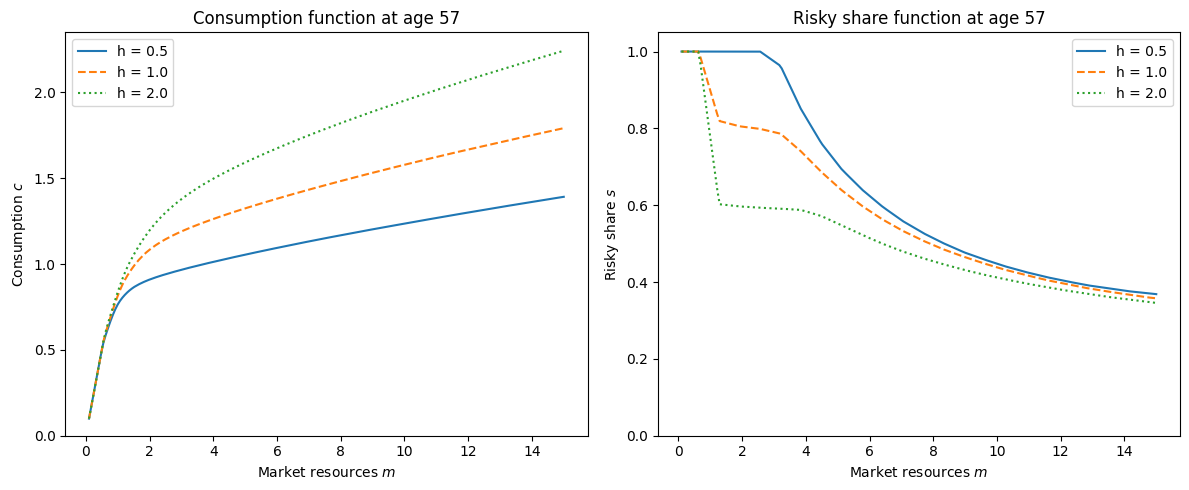

In [11]:
# [policy-functions-age-57]
sol_mid = HPtype.solution[35]  # roughly age 57
m_grid = np.linspace(0.1, 15, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for h_val, ls in [(0.5, "-"), (1.0, "--"), (2.0, ":")]:
    c_vals = [sol_mid["cFunc"](m, h_val) for m in m_grid]
    s_vals = [sol_mid["ShareFunc"](m, h_val) for m in m_grid]
    ax1.plot(m_grid, c_vals, ls, label=f"h = {h_val}")
    ax2.plot(m_grid, s_vals, ls, label=f"h = {h_val}")

ax1.set_xlabel("Market resources $m$")
ax1.set_ylabel("Consumption $c$")
ax1.set_title("Consumption function at age 57")
ax1.legend()
ax1.set_ylim(0, None)

ax2.set_xlabel("Market resources $m$")
ax2.set_ylabel("Risky share $s$")
ax2.set_title("Risky share function at age 57")
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### Simulate lifecycle paths

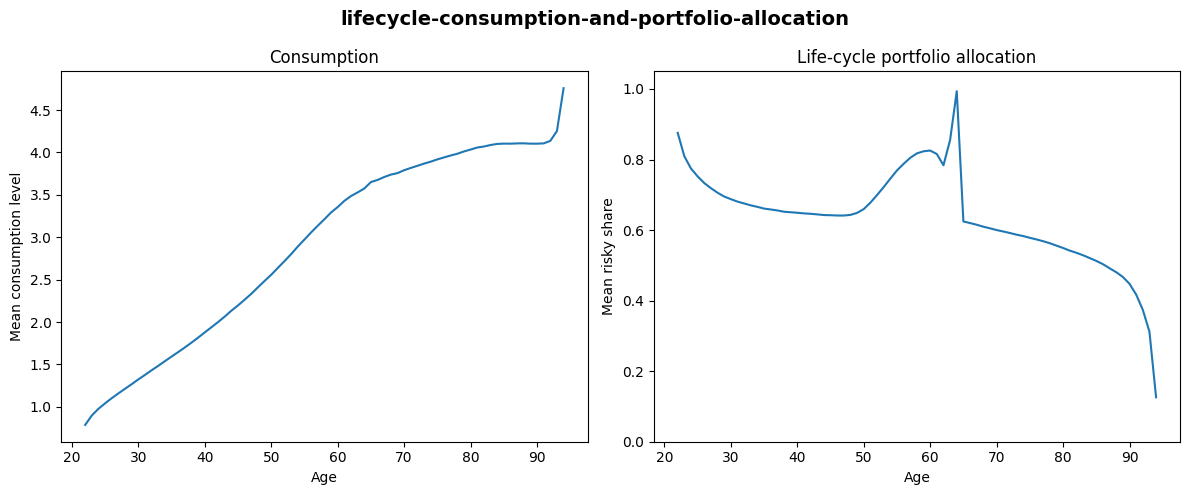

In [12]:
# [lifecycle-consumption-and-portfolio-allocation]
HPtype.T_sim = 73
HPtype.initialize_sym(stop_dead=False)
HPtype.symulate()

age_vec = np.arange(22, 95)
C_mean = np.mean(HPtype.hystory["cNrm"] * HPtype.hystory["pLvl"], axis=1)
S_mean = np.mean(HPtype.hystory["Share"], axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "lifecycle-consumption-and-portfolio-allocation", fontsize=14, fontweight="bold"
)
ax1.plot(age_vec, C_mean)
ax1.set_xlabel("Age")
ax1.set_ylabel("Mean consumption level")
ax1.set_title("Consumption")

ax2.plot(age_vec, S_mean)
ax2.set_xlabel("Age")
ax2.set_ylabel("Mean risky share")
ax2.set_title("Life-cycle portfolio allocation")
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### Compare with habit-only model

The habit-only model (with risk-free savings) provides a baseline. The portfolio model should show smoother consumption (due to higher expected returns) but also more volatility.

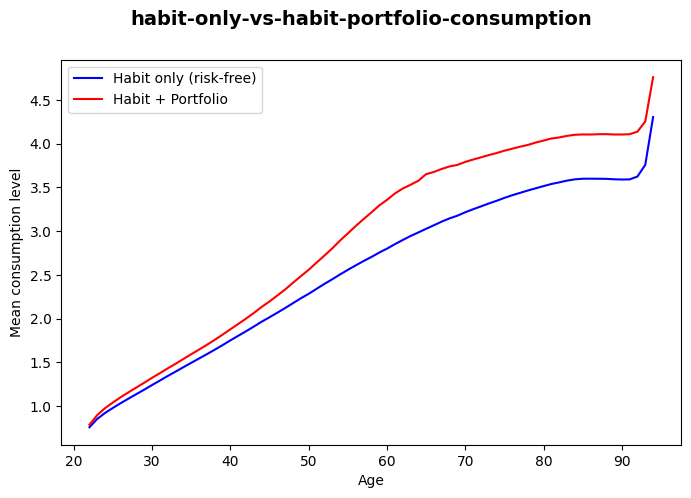

In [13]:
# [habit-only-vs-habit-portfolio-consumption]
Htype = HabitConsumerType(
    **{
        k: v
        for k, v in LC_params.items()
        if k not in ["RiskyAvg", "RiskyStd", "RiskyCount", "ShareCount"]
    }
)
Htype.solve()
Htype.T_sim = 73
Htype.initialize_sym(stop_dead=False)
Htype.symulate()

C_habit = np.mean(Htype.hystory["cNrm"] * Htype.hystory["pLvl"], axis=1)

fig = plt.figure(figsize=(8, 5))
fig.suptitle(
    "habit-only-vs-habit-portfolio-consumption", fontsize=14, fontweight="bold"
)
plt.plot(age_vec, C_habit, "-b", label="Habit only (risk-free)")
plt.plot(age_vec, C_mean, "-r", label="Habit + Portfolio")
plt.xlabel("Age")
plt.ylabel("Mean consumption level")
plt.legend()
plt.show()

### Asset accumulation: calibrating the time preference factor

Access to the equity premium raises expected returns and accelerates wealth accumulation.  If we gave both models the same time preference factor, the portfolio model would arrive at retirement much wealthier — not because its agents are more prudent, but simply because their investments earn more.  To isolate the *behavioral* effects of portfolio choice (rather than just the mechanical effect of higher returns), we recalibrate the discount factor `DiscFac` for the portfolio model so that both models produce approximately the same **level of assets at the brink of retirement** (age 64).

The habit-only model uses `DiscFac = 0.96`.  A bisection search (see `calibrate_DiscFac.ipynb`) finds that `DiscFac ≈ 0.849` in the portfolio model — substantially less patient — produces the same pre-retirement wealth.  The lower patience exactly offsets the higher returns: portfolio agents consume more at every age (funded by the equity premium), yet accumulate savings at the same rate as their risk-free counterparts.

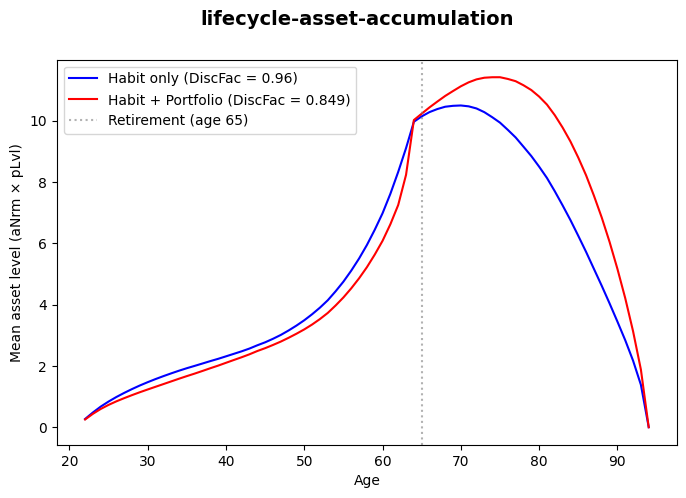

Mean assets at age 64 (brink of retirement):
  Habit only:       9.96
  Habit + Portfolio: 10.02
  Ratio:            1.006


In [14]:
# [lifecycle-asset-accumulation]
W_hp = np.mean(HPtype.hystory["aNrm"] * HPtype.hystory["pLvl"], axis=1)
W_h = np.mean(Htype.hystory["aNrm"] * Htype.hystory["pLvl"], axis=1)

fig = plt.figure(figsize=(8, 5))
fig.suptitle("lifecycle-asset-accumulation", fontsize=14, fontweight="bold")
plt.plot(age_vec, W_h, "-b", label="Habit only (DiscFac = 0.96)")
plt.plot(
    age_vec, W_hp, "-r", label=f"Habit + Portfolio (DiscFac = {DiscFac_portfolio})"
)
plt.axvline(65, color="gray", ls=":", alpha=0.6, label="Retirement (age 65)")
plt.xlabel("Age")
plt.ylabel("Mean asset level (aNrm × pLvl)")
plt.legend()
plt.show()

print("Mean assets at age 64 (brink of retirement):")
print(f"  Habit only:       {W_h[42]:.2f}")
print(f"  Habit + Portfolio: {W_hp[42]:.2f}")
print(f"  Ratio:            {W_hp[42] / W_h[42]:.3f}")

### The tragic shock experiment

At age 67 (simulation period 45), we halve the agent's wealth — a sudden, devastating loss.
With habits, consumption cannot adjust as freely as in the standard model because agents
are reluctant to let consumption deviate too far from their habit stock. We also examine
how the portfolio allocation responds: do agents take on more risk to try to rebuild wealth,
or do they become more conservative?

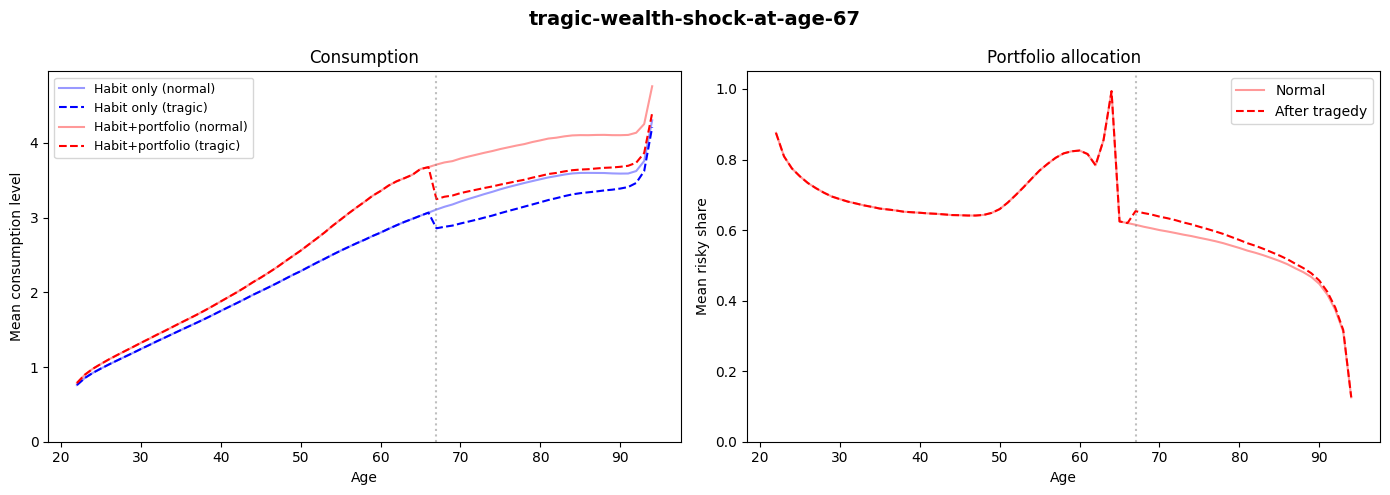

Immediate consumption change at age 67:
  Habit only (risk-free):     -6.84%
  Habit + portfolio:          -11.67%
  Portfolio share change:     +5.45%


In [15]:
# [tragic-wealth-shock-at-age-67]
# --- Normal simulation (no shock) ---
HPtype.T_sim = 73
HPtype.initialize_sym(stop_dead=False)
HPtype.symulate()
C_normal = np.mean(HPtype.hystory["cNrm"] * HPtype.hystory["pLvl"], axis=1)
S_normal = np.mean(HPtype.hystory["Share"], axis=1)

# --- Tragic shock: halve wealth at age 67 (period 45) ---
HPtype.initialize_sym(stop_dead=False)
HPtype.symulate(45)
HPtype._simulator.data["aNrm"] *= 0.5  # the horror, the horror!
HPtype.symulate()
C_tragic = np.mean(HPtype.hystory["cNrm"] * HPtype.hystory["pLvl"], axis=1)
S_tragic = np.mean(HPtype.hystory["Share"], axis=1)

# --- Same for the habit-only model ---
Htype.T_sim = 73
Htype.initialize_sym(stop_dead=False)
Htype.symulate()
C_habit_normal = np.mean(Htype.hystory["cNrm"] * Htype.hystory["pLvl"], axis=1)

Htype.initialize_sym(stop_dead=False)
Htype.symulate(45)
Htype._simulator.data["aNrm"] *= 0.5
Htype.symulate()
C_habit_tragic = np.mean(Htype.hystory["cNrm"] * Htype.hystory["pLvl"], axis=1)

# Consumption impact
age_vec = np.arange(22, 95)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("tragic-wealth-shock-at-age-67", fontsize=14, fontweight="bold")

ax1.plot(age_vec, C_habit_normal, "-b", alpha=0.4, label="Habit only (normal)")
ax1.plot(age_vec, C_habit_tragic, "--b", label="Habit only (tragic)")
ax1.plot(age_vec, C_normal, "-r", alpha=0.4, label="Habit+portfolio (normal)")
ax1.plot(age_vec, C_tragic, "--r", label="Habit+portfolio (tragic)")
ax1.axvline(67, color="gray", ls=":", alpha=0.5)
ax1.set_xlabel("Age")
ax1.set_ylabel("Mean consumption level")
ax1.set_title("Consumption")
ax1.legend(fontsize=9)
ax1.set_ylim(0, None)

ax2.plot(age_vec, S_normal, "-r", alpha=0.4, label="Normal")
ax2.plot(age_vec, S_tragic, "--r", label="After tragedy")
ax2.axvline(67, color="gray", ls=":", alpha=0.5)
ax2.set_xlabel("Age")
ax2.set_ylabel("Mean risky share")
ax2.set_title("Portfolio allocation")
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Percentage change at impact
pct_c_habit = 100 * (C_habit_tragic[45] - C_habit_tragic[44]) / C_habit_tragic[44]
pct_c_port = 100 * (C_tragic[45] - C_tragic[44]) / C_tragic[44]
pct_s_port = 100 * (S_tragic[45] - S_tragic[44]) / S_tragic[44]

print("Immediate consumption change at age 67:")
print(f"  Habit only (risk-free):     {pct_c_habit:+.2f}%")
print(f"  Habit + portfolio:          {pct_c_port:+.2f}%")
print(f"  Portfolio share change:     {pct_s_port:+.2f}%")

### Why consumption levels differ despite equal wealth

The left panel above shows that the habit+portfolio model has **higher consumption at every age**, even though both models have nearly identical wealth at retirement.  This is not an error — it reflects the equity premium.

Matching wealth at age 64 ensures both models have the same *stock* of savings, but not the same *income from savings*.  The portfolio agent earns roughly 4.2% on their wealth (risk-free rate plus the equity premium weighted by the risky share), compared to 3% for the risk-free agent.  On a wealth stock of ~10 units, that's 0.42 vs. 0.30 per year — about 40% more investment income.  This gap compounds: the portfolio agent's wealth actually *grows* during early retirement (despite higher consumption) because the equity premium more than covers the drawdown.

Over the full lifecycle, the portfolio agent consumes about 14% more in total than the risk-free agent.  The extra consumption is funded entirely by the equity premium — the reward for bearing investment risk.  The `DiscFac` calibration ensures both agents *save* at the same rate; they differ in how much their savings *earn*.

The right panel shows that the portfolio share **rises** slightly after the tragedy.  This is the standard "human wealth effect" in reverse.  An agent's total wealth has two components: *financial* wealth (savings) and *human* wealth (the present value of future labor income, which behaves like a bond).  Normally the large bond-like human wealth allows the agent to tilt their financial portfolio toward equities.  When the tragedy halves financial wealth, the ratio of human-to-financial wealth jumps — the agent is now "overweight bonds" relative to total wealth.  To rebalance, they shift their financial portfolio toward equities, raising the risky share.  This is exactly the mechanism identified by Bodie, Merton & Samuelson (1992) and Cocco, Gomes & Maenhout (2005), and is not specific to habits.

For comparing the **response to the tragic shock**, the relevant figure is the percentage deviation plot below, which normalizes each model by its own no-shock baseline.

### Consumption dynamics: percentage deviation from normal path

The level plots above can be hard to read because the two models have different
baseline consumption paths. Normalizing by the no-shock path isolates the
**dynamic response** to the wealth destruction — how quickly (or slowly) each
model's consumption recovers toward its pre-shock trajectory.

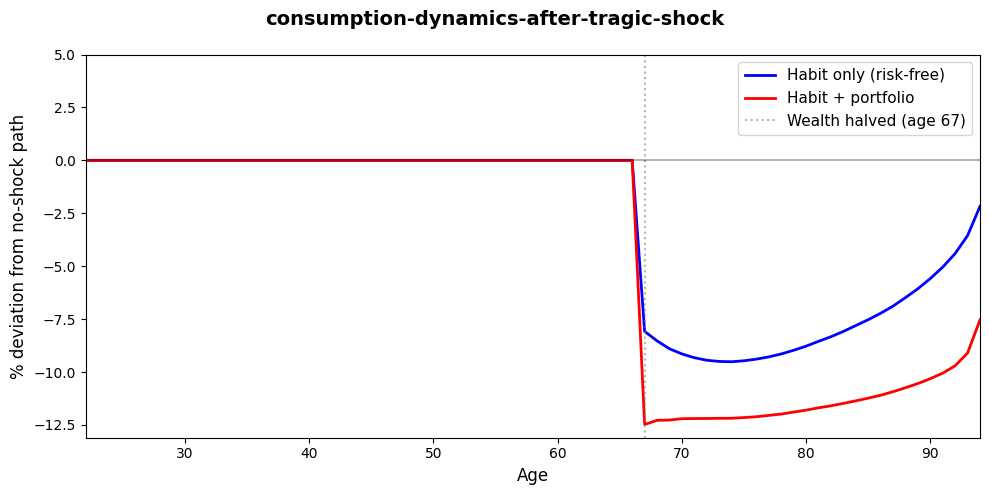


Peak consumption drop at age 67:
  Habit only:       -8.1%
  Habit + portfolio: -12.5%

Residual gap at age 80 (period 58):
  Habit only:       -8.8%
  Habit + portfolio: -11.8%


In [16]:
# [consumption-dynamics-after-tragic-shock]
pct_dev_habit = 100 * (C_habit_tragic - C_habit_normal) / C_habit_normal
pct_dev_port = 100 * (C_tragic - C_normal) / C_normal

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("consumption-dynamics-after-tragic-shock", fontsize=14, fontweight="bold")
ax.plot(age_vec, pct_dev_habit, "-b", linewidth=2, label="Habit only (risk-free)")
ax.plot(age_vec, pct_dev_port, "-r", linewidth=2, label="Habit + portfolio")
ax.axvline(67, color="gray", ls=":", alpha=0.6, label="Wealth halved (age 67)")
ax.axhline(0, color="black", ls="-", alpha=0.3)
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("% deviation from no-shock path", fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(22, 94)
ax.set_ylim(None, 5)
plt.tight_layout()
plt.show()

print("\nPeak consumption drop at age 67:")
print(f"  Habit only:       {pct_dev_habit[45]:+.1f}%")
print(f"  Habit + portfolio: {pct_dev_port[45]:+.1f}%")
print("\nResidual gap at age 80 (period 58):")
print(f"  Habit only:       {pct_dev_habit[58]:+.1f}%")
print(f"  Habit + portfolio: {pct_dev_port[58]:+.1f}%")